# Student Exam Performance – Exploratory & Confirmatory Data Analysis

##  1- Goal
---
We want to understand which academic, lifestyle, and socio-economic factors are associated with students’ final exam score Exam_Score.

## 2- Type of analysis :
----

- EDA – Exploratory Data Analysis 
- CDA – Confirmatory Data Analysis (Hypothesis Testing)

## 3- Key questions:
---
1- How is Exam_Score distributed?

2- Which factors show strong relationships with Exam_Score (e.g., study hours, attendance, sleep, motivation)?

3- Do students who participate in extracurricular activities perform differently from those who do not?

4- Does school type affect exam performance?

--------  

### 4-  Setup & loading

In [1]:
# Standard libraries
from pathlib import Path
import os

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub

# Configuration
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")
sns.set(font_scale=1.1)
np.random.seed(42)

# Paths (you can adjust if needed)
DATA_PATH = Path(".")

# Download latest version of the dataset from Kaggle
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")
print("Path to dataset files:", path)

# List files in the downloaded folder
print(os.listdir(path))

# Load the CSV file (adjust the name if different)
csv_path = os.path.join(path, "StudentPerformanceFactors.csv")
df = pd.read_csv(csv_path)


c:\Users\Dell\OneDrive\سطح المكتب\B5\content\W2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Dell\.cache\kagglehub\datasets\grandmaster07\student-exam-performance-dataset-analysis\versions\1
['StudentPerformanceFactors.csv']


### 5- Quick validation

In [2]:
df.shape

(6607, 20)

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [5]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

### 6- Check missing values

In [6]:
# Data cleaning & missing values
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

### 7- Handle missing values

Numeric features → filled with the median to reduce the impact of outliers.

Categorical features → filled with the mode to preserve the most common category.

In [7]:
# Handle missing values

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Fill numeric missing values with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

df.isna().sum()

C:\Users\Dell\AppData\Local\Temp\ipykernel_5448\1688248929.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

### 8- Univariate analysis

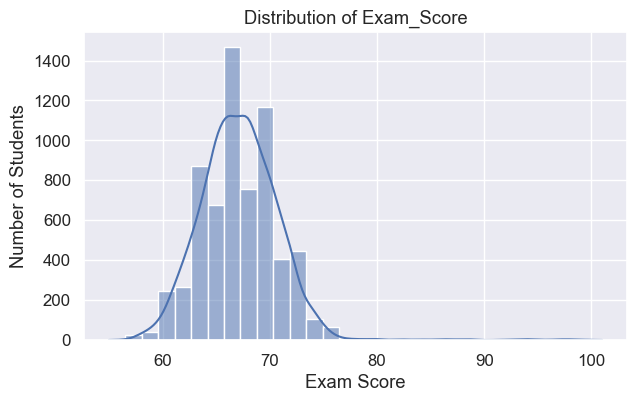

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [8]:
# Distribution of Exam_Score

plt.figure(figsize=(7,4))
sns.histplot(df["Exam_Score"], kde=True, bins=30)
plt.title("Distribution of Exam_Score")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

df["Exam_Score"].describe()

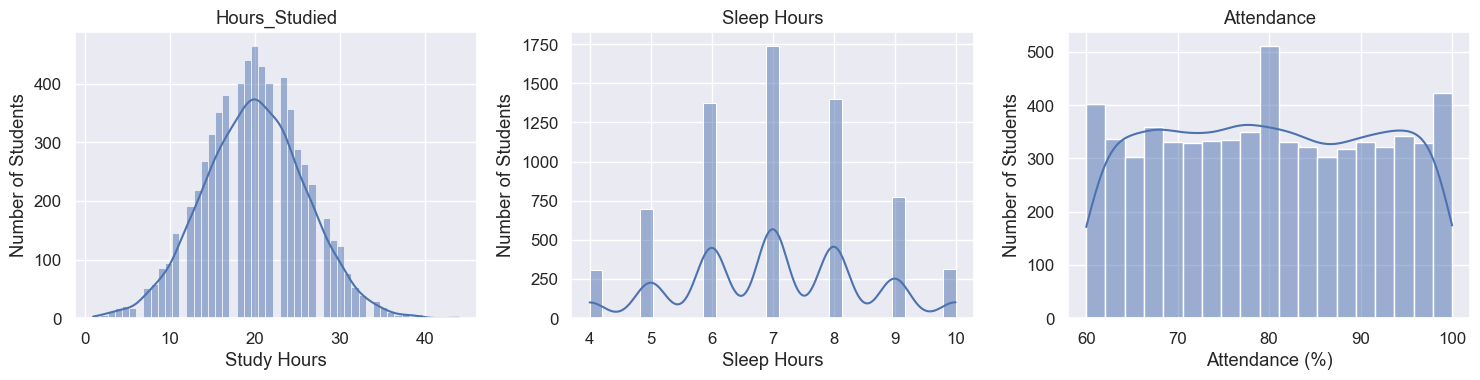

In [9]:
# Distributions of Hours_Studied, Sleep_Hours, Attendance

fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(df["Hours_Studied"], kde=True, ax=axes[0])
axes[0].set_title("Hours_Studied")
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Number of Students")

sns.histplot(df["Sleep_Hours"], kde=True, ax=axes[1])
axes[1].set_title("Sleep Hours")
axes[1].set_xlabel("Sleep Hours")
axes[1].set_ylabel("Number of Students")

sns.histplot(df["Attendance"], kde=True, ax=axes[2])
axes[2].set_title("Attendance")
axes[2].set_xlabel("Attendance (%)")
axes[2].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()


use small multiples to compare distributions of study hours, sleep hours, and attendance side by side.

-----

### 9- Bivariate analysis with Exam_Score

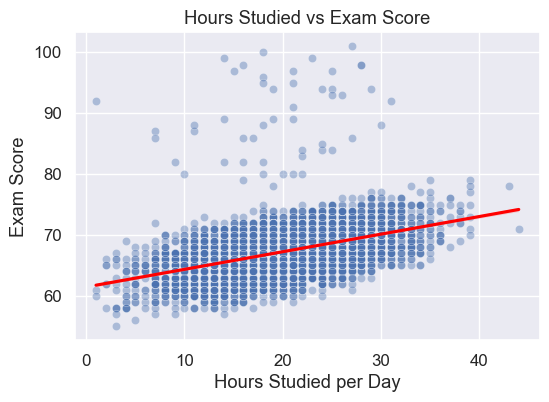

In [10]:
# Hours_Studied vs Exam_Score
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score", alpha=0.4)
sns.regplot(data=df, x="Hours_Studied", y="Exam_Score", scatter=False, color="red")
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied per Day")
plt.ylabel("Exam Score")
plt.show()

The regression line slopes upward, indicating a positive relationship: students who study more tend to score higher, with some natural variability.

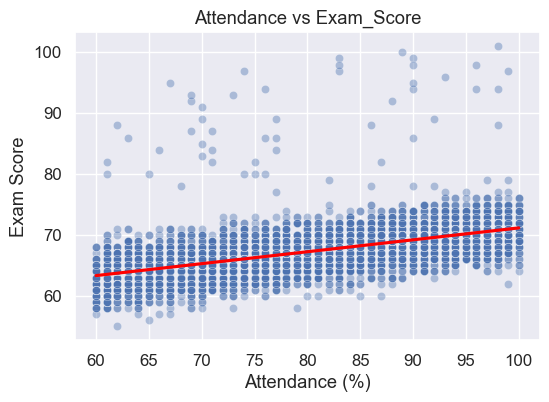

In [11]:
# Attendance vs Exam_Score
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Attendance", y="Exam_Score", alpha=0.4)
sns.regplot(data=df, x="Attendance", y="Exam_Score", scatter=False, color="red")
plt.title("Attendance vs Exam_Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.show()


Higher attendance is associated with higher exam scores, reinforcing the importance of regular class attendance.

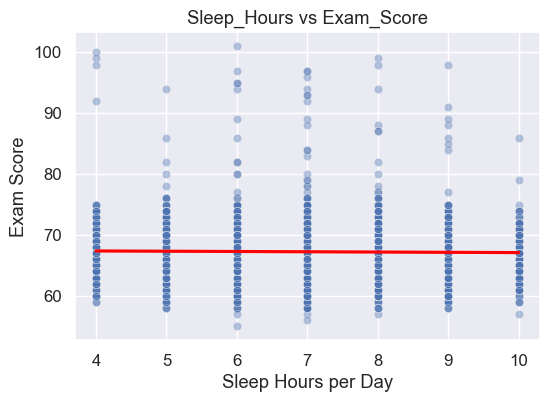

In [12]:
# Sleep_Hours vs Exam_Score
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Sleep_Hours", y="Exam_Score", alpha=0.4)
sns.regplot(data=df, x="Sleep_Hours", y="Exam_Score", scatter=False, color="red")
plt.title("Sleep_Hours vs Exam_Score")
plt.xlabel("Sleep Hours per Day")
plt.ylabel("Exam Score")
plt.show()

Moderate sleep duration (e.g., 7–8 hours) appears linked to better performance, while very low or very high sleep is associated with slightly lower scores.

-----------

### 10- Categorical vs target

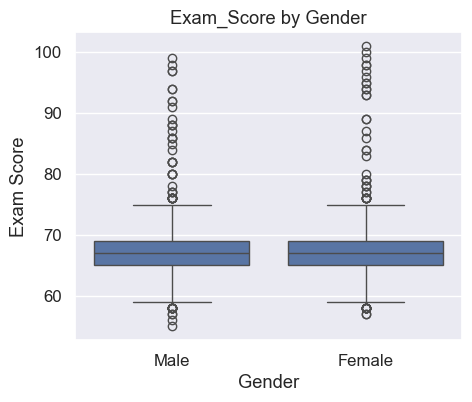

In [13]:
# Gender vs Exam_Score
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Gender", y="Exam_Score")
plt.title("Exam_Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Exam Score")
plt.show()


The boxplot shows that male and female students have very similar exam score distributions. Both groups share almost the same median and spread, indicating that gender does not have a significant impact on exam performance.

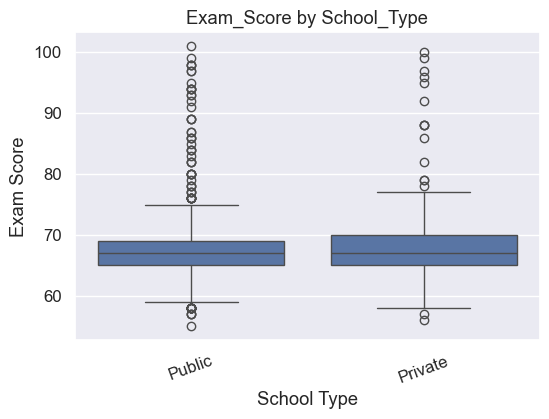

In [14]:
# School_Type vs Exam_Score
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="School_Type", y="Exam_Score")
plt.title("Exam_Score by School_Type")
plt.xlabel("School Type")
plt.ylabel("Exam Score")
plt.xticks(rotation=20)
plt.show()

Differences in medians and spread across school types suggest that school environment may influence exam performance.

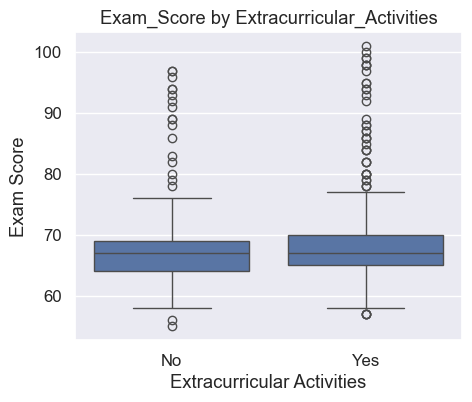

In [15]:
# Extracurricular_Activities vs Exam_Score
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Extracurricular_Activities", y="Exam_Score")
plt.title("Exam_Score by Extracurricular_Activities")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Exam Score")
plt.show()


The boxplot compares exam scores for students with and without extracurricular activities. Both groups show very similar medians and spreads, suggesting that participation in extracurricular activities does not lead to a large difference in exam performance.

--------

### 11- Correlation analysis

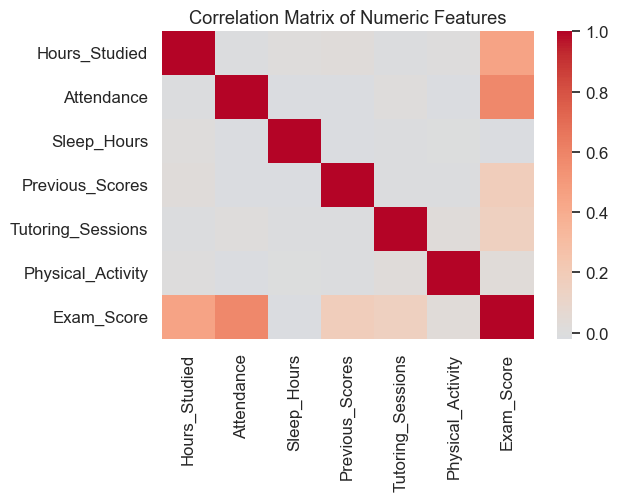

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64

In [16]:
plt.figure(figsize=(6,4))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

corr["Exam_Score"].sort_values(ascending=False)

We focus on the Exam_Score column to identify the strongest positive and negative correlations.

-------


### 12- Hypothesis testing

Extracurricular_Activities on Exam_Score (t-test)

Hypotheses:

H₀: There is no difference in the mean Exam_Score between students who have a Extracurricular_Activities and those who do not.

H₁: There is a difference in the mean between the two groups.

In [31]:
group_yes = df[df["Extracurricular_Activities"] == "Yes"]["Exam_Score"]
group_no = df[df["Extracurricular_Activities"] == "No"]["Exam_Score"]

t_stat, p_val = stats.ttest_ind(group_yes, group_no, equal_var=False)
t_stat, p_val, group_yes.mean(), group_no.mean()

(np.float64(5.282642343530676),
 np.float64(1.3191967683813616e-07),
 np.float64(67.44184865413915),
 np.float64(66.93143499437991))

If **p_val < 0.05** → reject H₀ → there is a significant difference between students with and without extracurricular activities.

Effect of School_Type on Exam_Score (ANOVA)

Hypotheses:

H₀: There is no difference in the mean Exam_Score between school types.

H₁: There is a difference in the mean for at least one school type.

In [18]:
groups = [g["Exam_Score"].values for _, g in df.groupby("School_Type")]
f_stat, p_val = stats.f_oneway(*groups)
f_stat, p_val


(np.float64(0.516606887291522), np.float64(0.4723181126216918))

If **p_val > 0.05** → fail to reject H₀ → no significant effect of school type on exam scores.

Correlation between Study_Hours and Exam_Score (Pearson)

Hypotheses:

H₀: There is no linear relationship between Motivation_Level and Exam_Score.

H₁: There is a linear relationship between them.

In [32]:
mapping = {"Low": 1, "Medium": 2, "High": 3}
df["Motivation_Level_Num"] = df["Motivation_Level"].map(mapping)

r_mot, p_mot = stats.pearsonr(df["Motivation_Level_Num"], df["Exam_Score"])
r_mot, p_mot

(np.float64(0.08693745565634078), np.float64(1.4557101467033387e-12))

If **p_val < 0.05** → reject H₀ → there is a significant (but weak) correlation.

------------

### 13- Summary

1. **Study hours matter:** There is a clear positive relationship between `Hours_Studied` and `Exam_Score`; students who study more tend to score higher.

2. **Previous performance is a strong predictor:** `Previous_Scores` shows one of the strongest correlations with `Exam_Score`, indicating that students who performed well before tend to maintain good performance.

3. **Attendance is important:** Higher `Attendance` is associated with higher exam scores, highlighting the importance of regular class attendance.

4. **Sleep balance helps:** Moderate `Sleep_Hours` appears linked to better performance, while very low or very high sleep is associated with slightly lower scores.

5. **Parental involvement and school environment:** Higher `Parental_Involvement` and certain `School_Type` categories are associated with better exam performance, suggesting that family support and school quality both matter.

6. **Extracurricular activities:** The t-test shows a `significant` difference, `with` students with extracurricular activities having a `slightly higher but practically similar` average Exam_Score.

7. **Motivation as a psychological factor:** After encoding `Motivation_Level`, we found a positive and statistically significant correlation with `Exam_Score`, supporting the idea that motivated students tend to achieve higher ## Summary & Key Insights